# Lab 2: Linear Regression & Logistics Regression

**Student Name:** Amelia Nguyen

**Date:** January 30, 2026

In [ ]:
!pip3 install ISLP

In [159]:
# Import Libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import *
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score

## Question 1: 5-question multiple choice
Completed on website.

## Question 2: Carseats data
Information about car seat sales in 400 stores. The data set is available in ISLR2 package.

### Q2(a)
Fit a multiple regression model to predict Sales using Price, Urbam, and US, and find the fitted line.

In [4]:
df = load_data("Carseats")

In [5]:
df.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [13]:
model = smf.ols(formula='Sales ~ Price + Urban + US', data=df)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           2.39e-23
Time:                        11:17:28   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036      0.000      11.764      14.323
Urban[T.Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[T.Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
Price           -0.0545      0.005    -10.389      0.000      -0.065      -0.044
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The fitted line:
$$\hat{Sales} = 13.0435 - 0.0545Price - 0.0219Urban(Yes) + 1.2006 US(Yes)$$

### Q2(b)
According to model fitting results, please provide an interpretation of each regression coefficient. (Be careful some of the variables in the model are qualitative)

**Answer**: 
* Beta0 = 13.0435: The sales for car seats is estimated to be 13.0435 when Price = 0 and not in either the Urban area or the US. It serves as the baseline for the model only because Price normally takes a value larger than 0.
* Beta1 = -0.0545: For each unit increase in price, sales for car seats is estimated to decrease by 0.0545 units.
* Beta2 = -0.0219: The sales is estimated to be 0.0219 lower in Urban stores compared to non-Urban stores, holding other variables constant.
* Beta3 = 1.206: The sales is estimated to be 1.2006 higher in the US stores compared to non-US stores.

### Q2(c)

Conduct the test H0 : βprice = 0. Please set up the hypothesis, test statistic, rejection region and make a decision.

**Answer:**

Hypothesis:
    
- $H_0: \beta_{\text{price}} = 0$ (Price has no effect on Sales)
- $H_a: \beta_{\text{price}} \neq 0$ (There is effect of price on sales)
      

Test Statistics:
- t = $\hat\beta_{\text{price}}/SE(\hat\beta_{\text{price}}) = -0.0545/ 0.005 = -10.9$

Rejection Region: 
- df = n - p - 1 = 400 - 3 - 1 = 396
- $t_c$ at alpha = 0.05, df = 396: +- 1.96
  
=> RR: Reject $H_0$ if $t > t_c/2$ or $t < -t_c$

Decision:
* As t statistics = -10.9 which is much smaller than $-t_c$, we reject $H_0$
* Conclusion: There is a strong evidence that Price is a significant predictor of Sales for car seats. The negative sign of coefficient indicates an one-unit increase in Price is estimated to result in a 0.0545 decrease in Sales.

### Q2(d)
Please predict Sales when Price = 60, Urban = No, and US= No

In [19]:
Price = 60
Urban = 0
US = 0
pred_sales = 13.0435 - 0.0545 * Price - 0.0219 * Urban + 1.2006 * US
print(f"Predicted Sales = {pred_sales}")

Predicted Sales = 9.7735


## Question 3: Carseats data, based on Question 2

### Q3(a)
Fit a reduced model that only uses the important predictors (significant predictors) associated with the response variable (Sale)

**Answer:** From the Q2(a), Urban has Pvalue = 0.9 > 0.05, indicates that Urban is not an important predictors. Therefore, in this problem, we only fit Price and US to predict Sales.

In [20]:
model = smf.ols(formula='Sales ~ Price + US', data=df)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           2.66e-24
Time:                        16:17:27   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.000      11.790      14.271
US[T.Yes]      1.1996      0.258      4.641      0.000       0.692       1.708
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Q3(b)
According to part a model, draw the residual plots to check the assumptions of random error.

**Answer:**

"Residuals vs Fitted Values" and Q-Q plot indicates random error assumption in the model.

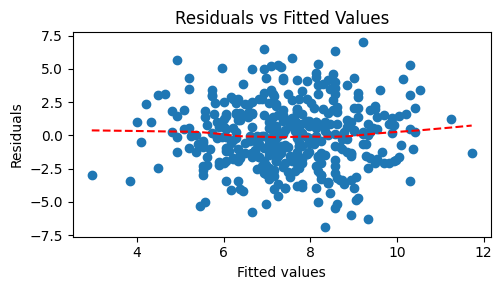

In [67]:
plt.figure(figsize=(5, 3))
fitted_vals = results.fittedvalues
residuals = results.resid
plt.scatter(fitted_vals, residuals)
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, fitted_vals)
plt.plot(smoothed[:, 0], smoothed[:, 1], color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

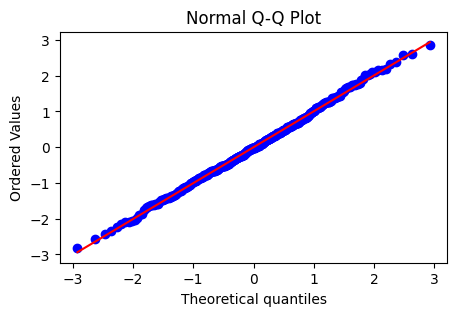

In [69]:
plt.figure(figsize=(5, 3))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot')
plt.show()

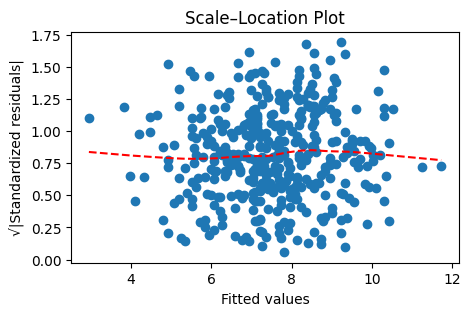

In [62]:
plt.figure(figsize=(5, 3))
fitted_vals = results.fittedvalues
influence = results.get_influence()
standardized_residuals = influence.resid_studentized_internal
scale_location = np.sqrt(np.abs(standardized_residuals))
plt.scatter(fitted_vals, scale_location)
plt.xlabel("Fitted values")
plt.ylabel("√|Standardized residuals|")
plt.title("Scale–Location Plot")
lowess = sm.nonparametric.lowess
smoothed = lowess(scale_location, fitted_vals)
plt.plot(smoothed[:, 0], smoothed[:, 1], color="red", linestyle="--")
plt.show()


### Q3(c)
Check whether Carseats data has any outliers or not.

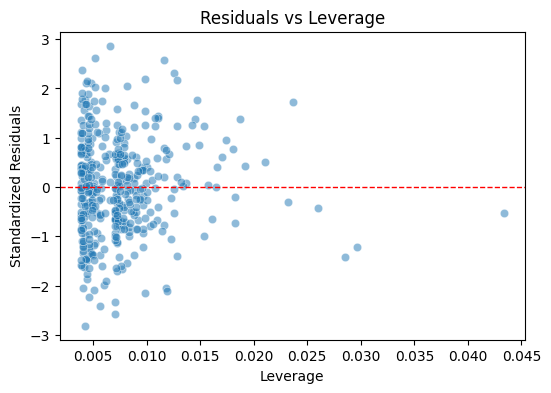

In [70]:
influence = results.get_influence()
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(6, 4))
sns.scatterplot(x=leverage, y=norm_residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.title('Residuals vs Leverage')
plt.show()

According to the Residuals and Leverage plot, there are signs of potential outliers in the data as there are points with high standardized residuals.

### Q3(d)
Using the model from (a), obtain 90% confidence intervals for the coefficient(s).

In [72]:
summarize(results)

,coef,std err,t,P>|t|
Intercept,13.0308,0.631,20.652,0.0
US[T.Yes],1.1996,0.258,4.641,0.0
Price,-0.0545,0.005,-10.416,0.0


In [74]:
conf_interval = results.conf_int(alpha=0.10)
conf_interval.columns = ["Lower Bound", "Upper Bound"]

In [75]:
conf_interval

,Lower Bound,Upper Bound
Intercept,11.990502,14.071084
US[T.Yes],0.773518,1.625768
Price,-0.063101,-0.045855


## Question 4: 
Suppose a set of data (n = 100 observations) containing a single predictor and a quantitative response. A linear regression model is fit to the data, as well as a separate cubic regression, i.e. 
Y =β0 + β1X + β2X2 + β3X3 + ϵ.

### Q4(a)
Suppose that the true relationship between X and Y is linear, i.e. Y = β0 + β1X + ϵ. Consider the test residual sum of squares (MSE) for the linear regression, and also the test MSE for the cubic regression. Would we expect one to be lower than the other, would we expect them to be the same, or is there not enough information to tell?

**Answer:** The test MSE for linear regression is expected to be lower than that for cubic regression as the true relationship between X and Y is linear. Even though cubic regression seems to be more flexible as it fits data more closely on the training set, it will not fit well to unseen data on the test set compared to linear regression, given the true relationship is linear.

### Q4(c)
Suppose that the true relationship between X and Y is not linear, but we don’t know how far it is from linear. Consider the test MSE for the linear regression, and also the test MSE for the cubic regression. Would we expect one to be lower than the other, would we expect them to be the same, or is there not enough information to tell?.

**Answer:** There is not enough information to tell. Generally speaking, cubic regression is estimated to have lower test MSE because it is more flexible. As we don't know how far the true model is from linear, we cannot decide on how high could the bias be. If the model is really far from linear, the bias of linear regression will be high, then cubic regression whose bias is low will have lower test MSE. However, if the true relationship is just slightly non-linear, it can be possible that linear regression can achieve lower MSE as bias then is low and variance is also low, compared to cubic regression whose variance is high. To better assess which model to choose, we should need more information about the noises, training size, etc.

## Question 5:
Suppose we collect data for a group of students in a statistics class with variables X1 =hours studied, X2 =undergrad GPA, and Y = receive an A. We fit a logistic regression and produce estimated coefficient,  $\hat\beta_0 = −6,  \hat\beta_1 = 0.05,  \hat\beta_2 = 1$.

### Q5(a):
Estimate the probability that a student who studies for 40 h and has an undergrad GPA of 3.5 gets an A in the class.

**Answer:**

The logistics regression equation:
$\hat\log(p/(1-p)) = \beta_0 + \beta_1x_1 + \beta_2x_2 $ 

$=> p = exp(\beta_0 + \beta_1x_1 + \beta_2x_2) - exp(\beta_0 + \beta_1x_1 + \beta_2x_2) p$

$=> p(1 + exp(\beta_0 + \beta_1x_1 + \beta_2x_2)) = exp(\beta_0 + \beta_1x_1 + \beta_2x_2)$

$=> p = exp(\beta_0 + \beta_1x_1 + \beta_2x_2)/(1+ exp(\beta_0 + \beta_1x_1 + \beta_2x_2))$



=> The probability equation:
$Pr = exp(-6 + 0.05x_1 + 1x_2)/ (1 + exp(-6 + 0.05x_1 + 1x_2))$ 

In [82]:
prob = math.exp(-6 + 0.05 * 40 + 3.5)/ (1 + math.exp(-6 + 0.05 * 40 + 3.5))
print(f"Probability = {round(prob*100,2)}%")

Probability = 37.75%


### Q5(b)
Calculate the odds and log odds that a student who studies for 40 h and has an undergrad GPA of 3.5 gets an A in the class.

**Answer:**
From the logistics regression equation written in part (a):

In [88]:
odds = math.exp(-6 + 0.05 * 40 + 3.5)
print(f"Odds = {round(odds,2)}")

Odds = 0.61


In [89]:
log_odds = -6 + 0.05 * 40 + 3.5
print(f"Log Odds = {round(log_odds,2)}")

Log Odds = -0.5


### Q5(c)
How many hours would the student in part (a) need to study to have a 50% chance of getting an A in the class

**Answer:**

$0.5 = exp(-6 + 0.05x_1 + 3.5)/(1+exp(-6 + 0.05x_1 + 3.5)$

$=> 0.5 + 0.5exp(-2.5 + 0.05x_1) = exp(-2.5 + 0.05x_1)$

$=> 0.5 = 0.5exp(-2.5 + 0.05x_1)$

$=> -2.5 + 0.05x_1 = log(0.5/0.5)  = log(1)$

$=> -2.5 + 0.05x_1 = 0$

$=> x_1 = 2.5/0.05 = 50$

Conclusion: This student needs to study 50 hours to have a 50% chance of getting an A.

## Question 6: Auto data

### Q6(a)
Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() function. Note you may find it helpful to use the data.frame() function to create a single data set containing both mpg01 and the other Auto variables.

In [129]:
auto = load_data("Auto")

In [91]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [133]:
mpg_median = auto['mpg'].median()
auto['mpg01'] = (auto['mpg'] > mpg_median).astype(int)

In [131]:
mpg_median

np.float64(22.75)

In [141]:
auto[auto.mpg > 22.75][["mpg", "mpg01"]].head(1)

,mpg,mpg01
name,,
toyota corona mark ii,24.0,1


In [94]:
auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'mpg01'],
      dtype='object')

## Q6(b)
Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots may be useful tools to answer this question. Describe your findings.


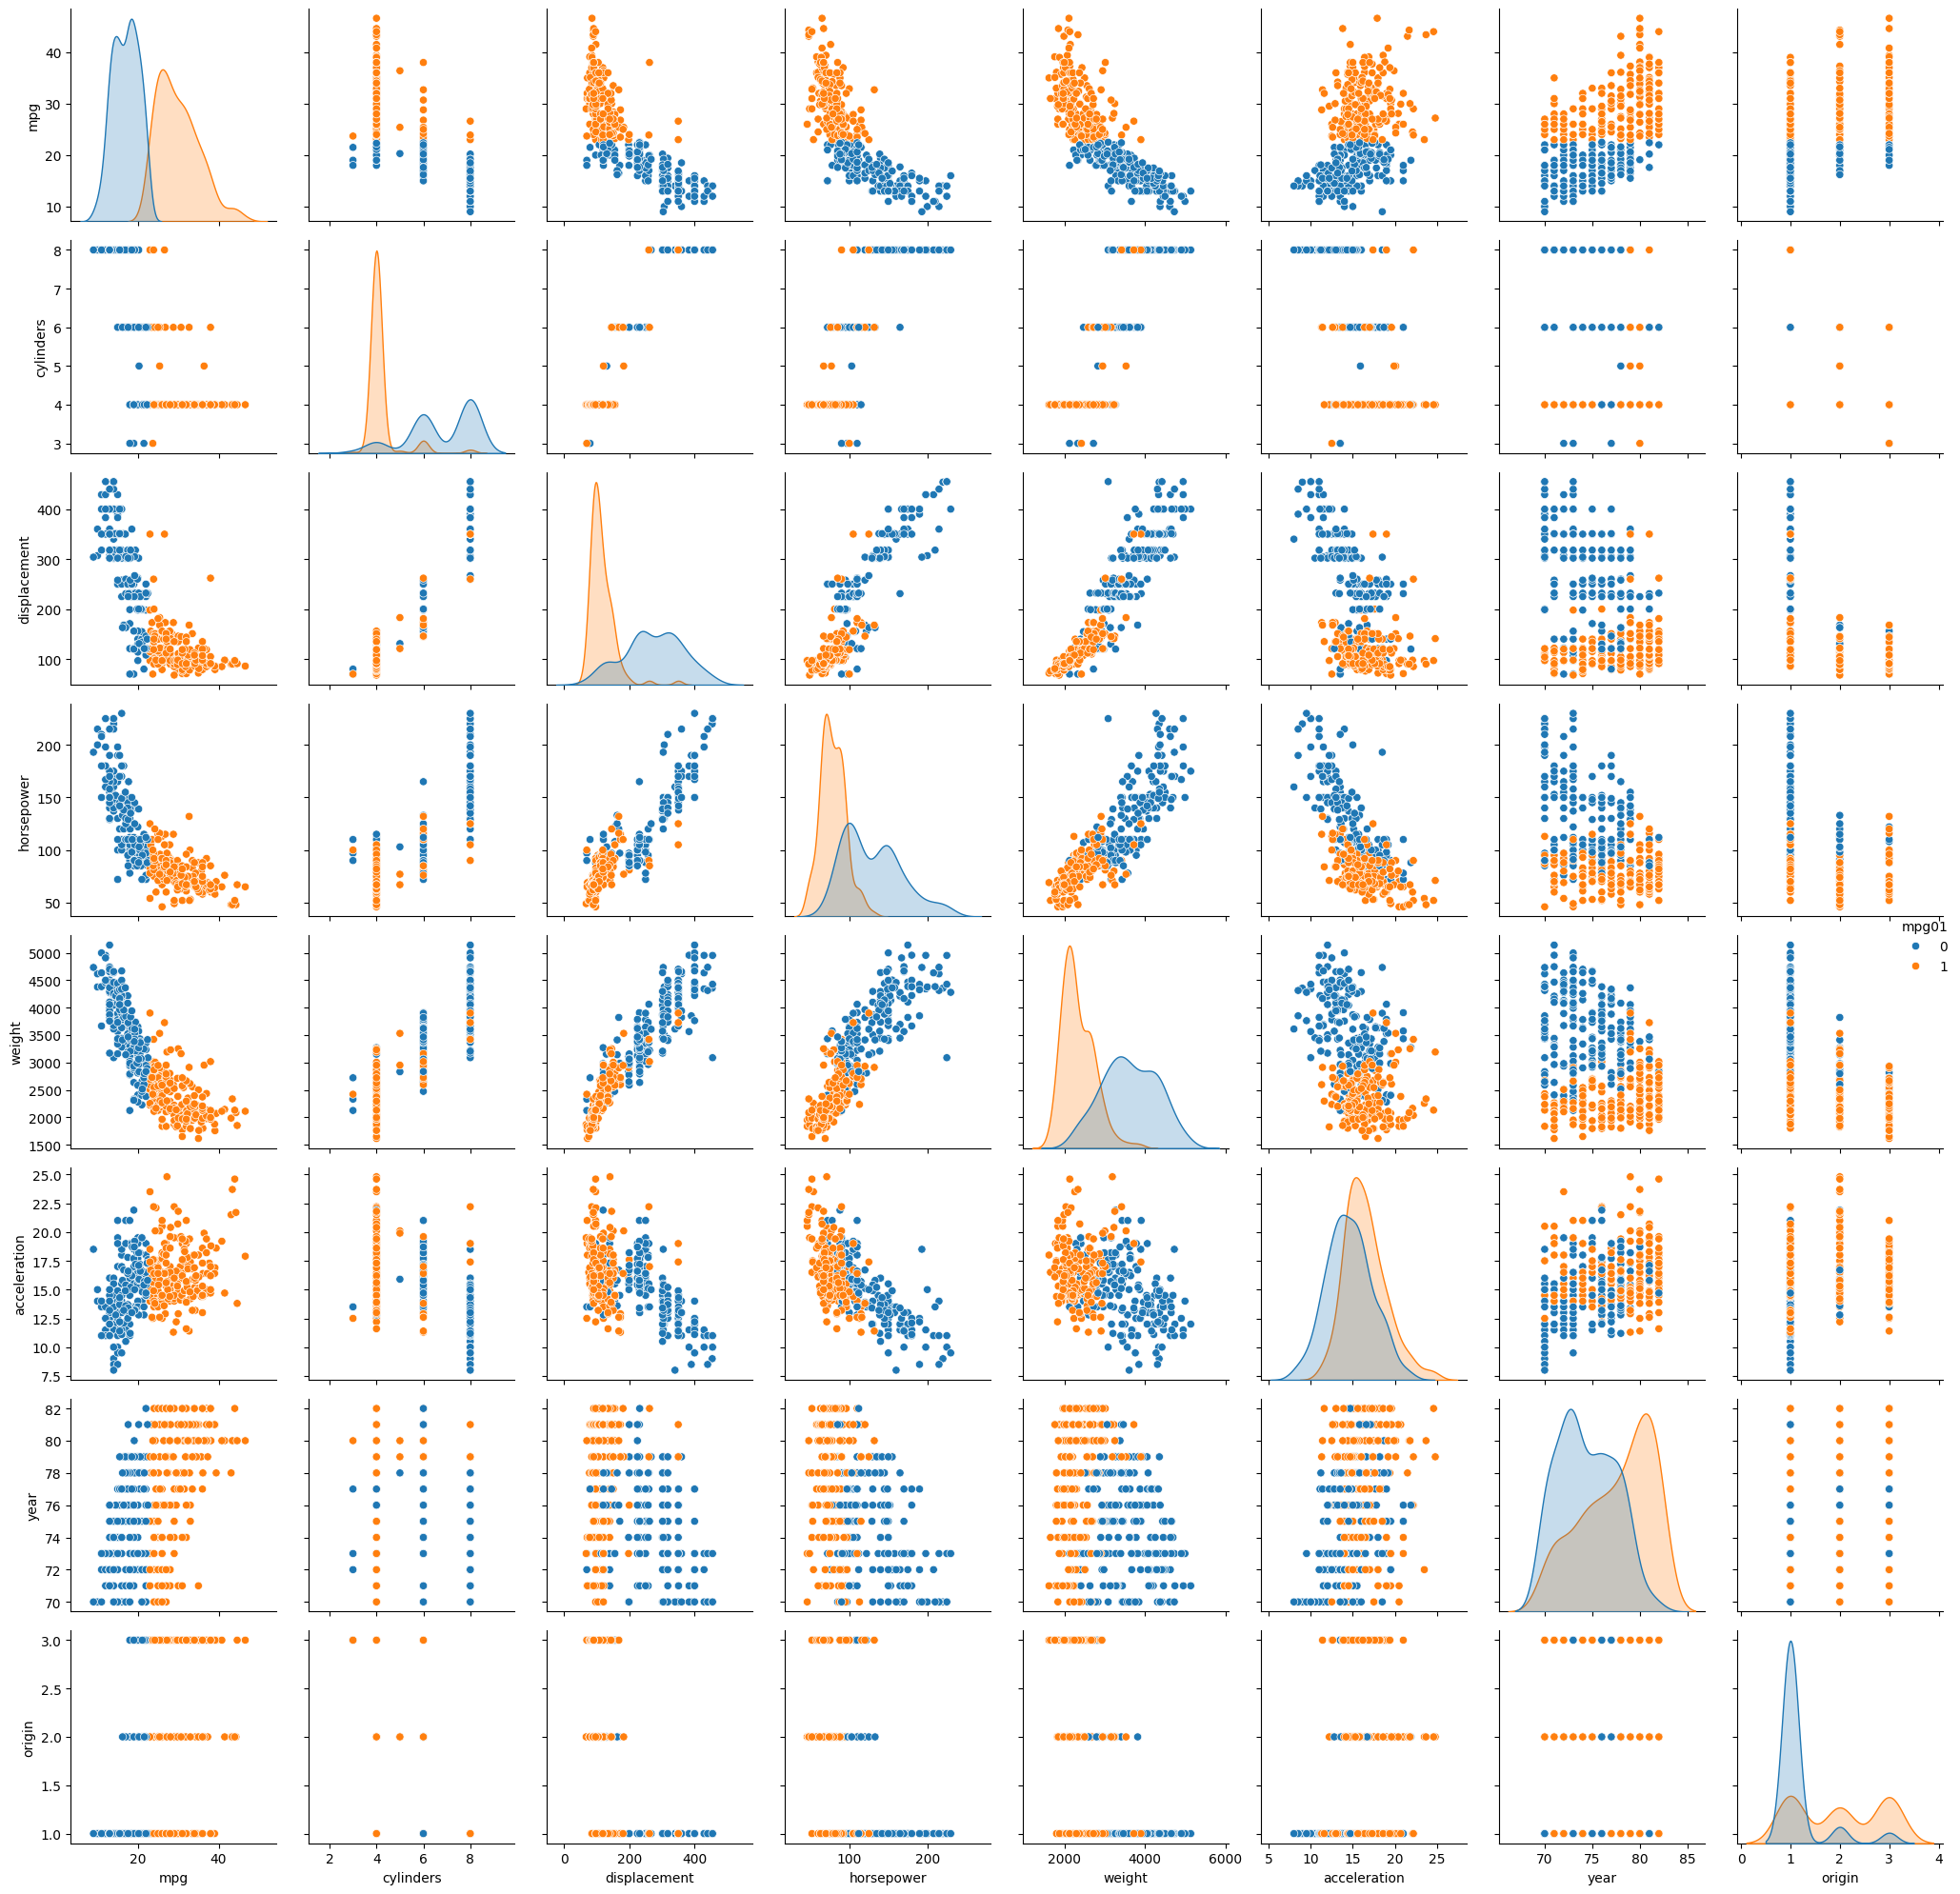

In [110]:
sns.pairplot(auto, hue="mpg01")
plt.tight_layout()
plt.show()

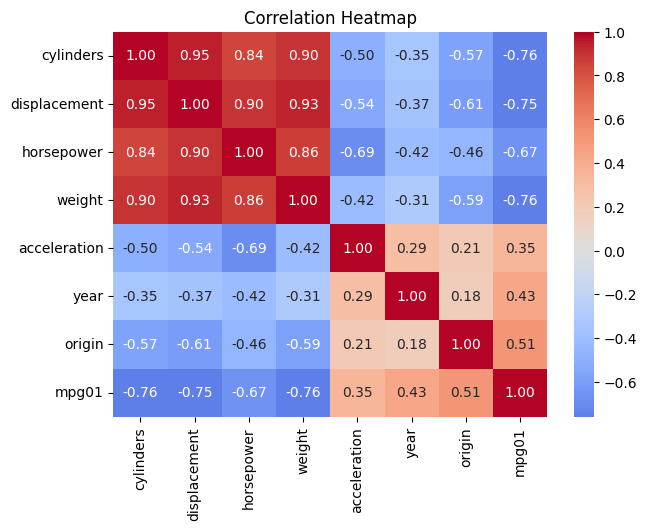

In [118]:
auto_new = auto.drop(columns={"mpg"})
corr = auto_new.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

The features seem to be most useful in predicting mpg01 are: cylinders, displacements, weight, horsepower, origin

### Q6(c): 
Split the data into a training set (90%) and a test set (10%).

In [122]:
X = auto.drop(columns=['mpg', 'mpg01'])
y = auto['mpg01']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 352
Test set size: 40


In [126]:
X_train.shape[0]/auto.shape[0]

0.8979591836734694

In [127]:
X_test.shape[0]/auto.shape[0]

0.10204081632653061

### Q6(d)
Perform logistic regression on the training data in order to predict mpg01 using two variables (cylinders and horsepower) that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [150]:
X_train = X_train[['cylinders', 'horsepower']]
X_test = X_test[['cylinders', 'horsepower']]
log_reg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [161]:
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

In [162]:
confusion_matrix(y_test, y_pred)

array([[16,  4],
       [ 2, 18]])

In [163]:
test_error = 1 - accuracy_score(y_test, y_pred)
print(f"Test Error: {round(test_error,2)}")

Test Error: 0.15
